# Exploring $P_{dem}$: Bring back the joy in Polarization

## By Trevor Tibbetts
### GEOG 585 Final Project
###5/4/2026

Abstract: This project adopts the role of a data analyst for an upcoming democratic campaign, tasked with identifying focus regions based on the 2016 presidential election results. By synthesizing a handful of spaital analysis methods, I identify stable partisan strongholds versus contested political islands. The results demonstrat how the $S$ statisitic can be used by campaign managers to quantify the spatial polarization of the electorate and optimes resouce allocation in a polarized landscape.   


Problem Statement: How is the electorate spatailly partitioned into contigous political componates, and how do measures of local heterogeneity (LOSH) and regionalization algorithms reveal the boundaries of these polarizaed regions? This analysis seeks to determine if graph based regionalizen (SKATER) or heirarchical clustering (Ward) more accuralty capture the complex landscape of voter distribution.   

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import libpysal as lps
import esda
from esda.moran import Moran

### Imports and Data Wrangling

Data Source: 2016 Presidential Election Results - Precent Level
*   Note: The CONUS GPKG file is to large to run in Colab. The data is trimmed to feature a specific state in cell four. The interpretation of this analysis is based on the Illinois subset, though this project can be extended to analyze states in the contiguous United States.


Primary Variable: $P_{dem}$ = Percent Democratic vote share $$DemVotes_i /  RepVotes_i + DemVotes_i $$

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
## Data import
path = "/content/drive/MyDrive/data/2016conusPrec.gpkg"
gdf = gpd.read_file(path, engine="pyogrio")

print(gdf.head())

   G16PRERTRU  G16PREDCLI STATE    perdem  \
0         327         110    pa  0.251716   
1         386         120    pa  0.237154   
2         622         200    pa  0.243309   
3         677         161    pa  0.192124   
4         340         158    pa  0.317269   

                                            geometry  
0  MULTIPOLYGON (((-78.94597 40.44195, -78.93953 ...  
1  MULTIPOLYGON (((-78.81082 40.31335, -78.81064 ...  
2  MULTIPOLYGON (((-78.87254 40.29766, -78.87253 ...  
3  MULTIPOLYGON (((-78.86338 40.45068, -78.86331 ...  
4  MULTIPOLYGON (((-78.86992 40.29672, -78.86989 ...  


In [4]:
IL = gdf[gdf.STATE.isin(['il'])].reset_index()
## Fun Trick: Change the state by replacing ['il'] with any state abbreviation

In [5]:
IL.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 10090 entries, 0 to 10089
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   index       10090 non-null  int64   
 1   G16PRERTRU  10090 non-null  int64   
 2   G16PREDCLI  10090 non-null  int64   
 3   STATE       10090 non-null  object  
 4   perdem      10088 non-null  float64 
 5   geometry    10090 non-null  geometry
dtypes: float64(1), geometry(1), int64(3), object(1)
memory usage: 473.1+ KB


In [6]:
IL = IL.dropna(subset=['perdem']).reset_index(drop=True)

## Methods: Morans I, LOSH, $S$, Spatial Regimes (Ward & SKATER)

### Modual 1 Baseline: Global and Local ESDA

This modual is aimed to decribe the clustering and variation of the vote share. Here Moran's I is employed to detect autocorrelation that tells us if the vote share has clustering of similar values in space. Then LOSH is used to detect the variance in the vote share by evaluating the neighbors of a precinct to see if the precinct is similar or dissimilar.

In [7]:
from splot.esda import moran_scatterplot


In [8]:
weights= lps.weights.Queen.from_dataframe(IL)
weights.transform = "r"

/tmp/ipykernel_88814/365553043.py:1: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  weights= lps.weights.Queen.from_dataframe(IL)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


In [9]:
y= IL["perdem"]

globalM= Moran(y, weights)
print("Global Moran's I:", round(globalM.I,4), "| p:", globalM.p_sim)


Global Moran's I: 0.9366 | p: 0.001


In [10]:
## Local Moran (lm)
lm = esda.Moran_Local(y, weights)
print("Local Moran's I:", lm.Is)


Local Moran's I: [2.60964772e+00 2.47705655e+00 2.84985338e+00 ... 3.58673421e-01
 9.89440102e-02 8.59125052e-04]


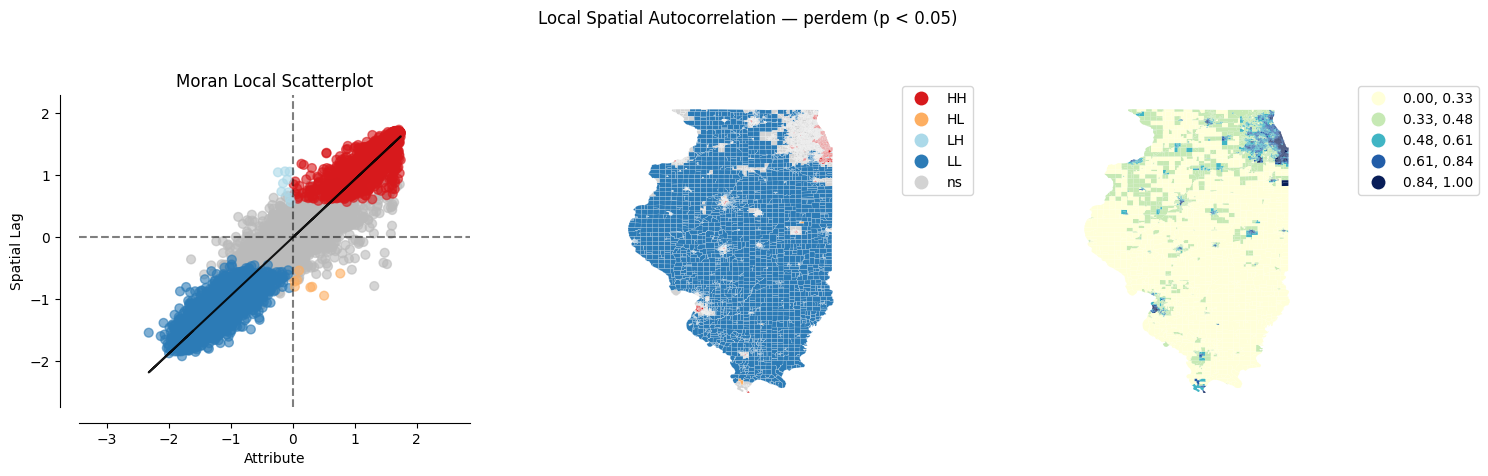

In [11]:
import splot.esda
import matplotlib.pyplot as plt

primary_p = 0.05
fig = splot.esda.plot_local_autocorrelation(lm, IL, 'perdem', p=primary_p, figsize=(15, 5))

# 4. Correct the title and display
plt.suptitle(f"Local Spatial Autocorrelation — perdem (p < {primary_p})")
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust to make room for suptitle
plt.show()

#### Autocorrelation Interpretation
Moran's I value is near one. Meaning that there is strong autocorrelation.

### Modual 1 Extension: LOSH

Taking a look at the variance within the clustering

In [12]:
from esda.losh import LOSH

In [13]:
w = lps.graph.Graph.build_fuzzy_contiguity(IL)

In [14]:
loshResults = LOSH(connectivity=w, inference="chi-square").fit(y)

In [15]:
loshResults

LOSH(connectivity=<Graph of 10088 nodes and 63280 nonzero edges (1 component, 0 isolates) indexed by
 [0, 1, 2, 3, 4, ...]>,
     inference='chi-square')

In [16]:
loshResults.Hi[0:10]

array([1.47154706, 0.83341895, 0.288195  , 0.39230122, 0.71481408,
       0.32321864, 0.92806031, 0.4656491 , 0.2428202 , 0.21401835])

In [17]:
loshResults.pval[0:10]

array([0.22604309, 0.4411413 , 0.68854207, 0.6568177 , 0.24551834,
       0.79064302, 0.38810876, 0.70937174, 0.76454053, 0.87084026])

In [18]:
IL["Hi"] = loshResults.Hi
IL["Hi_pval"] = loshResults.pval

#### Interpreting LOSH:

LOSH is typically interpreted along side with G*. Although for this test Moran's I was computed for a baseline to detect autocorrelation. Strong autocorrelation was detected which is used to interprete LOSH.

High $H_i$ -> A hot spot with heterogeneous local conditions

Low $H_i$ ->  A hot spot with similar surrounding areas; the map would indicate whether the affected region is larger than the single ‘cell’

<Axes: >

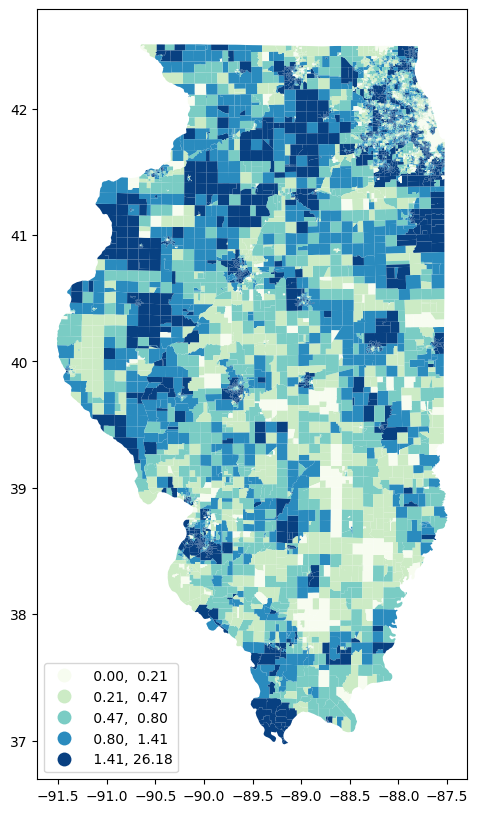

In [19]:
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={"aspect": "equal"})
IL.plot(
    column="Hi",
    scheme="Quantiles",
    k=5,
    cmap="GnBu",
    legend=True,
    ax=ax,
    legend_kwds={
        'loc': 'lower left',
        'bbox_to_anchor': (0, 0),
        'fmt': "{:.2f}"
    }
)

### The S Bridge

This bridge serves to show the spatial polarization of the dataset. A high $S$ near 1 would detect a few intersection componates of geographic and atribute adancy. A value near 0 would resemble 'salt and peper' in the intersection graph meaning democratic precincts are not adjcent with republican precincts for vice versa.

In [20]:
# Polarization Function PY Sharable Link: https://drive.google.com/file/d/1_Mo1YxDKWrh58w-c5HnMQ7TTJ48mwSVB/view?usp=sharing

from polarization1 import S


In [21]:
PolarResults= S(IL, w, "perdem", k=5, permutations=999)

100%|██████████| 999/999 [00:58<00:00, 17.20it/s]


In [22]:
PolarResults

S Spatial Polarization Summary
Variable:                                        perdem
n:                                                10088
-------------------------------------------------------
S:                                               0.9328
p-value:                                         0.0010
permutations:                                       999
-------------------------------------------------------
Number of attribute components:                       5
Number of spatial components:                         1
Number of intersection components:                  683

In [23]:
IL['labs']=PolarResults.labels.i_labels
IL['alabs']=PolarResults.labels.i_labels

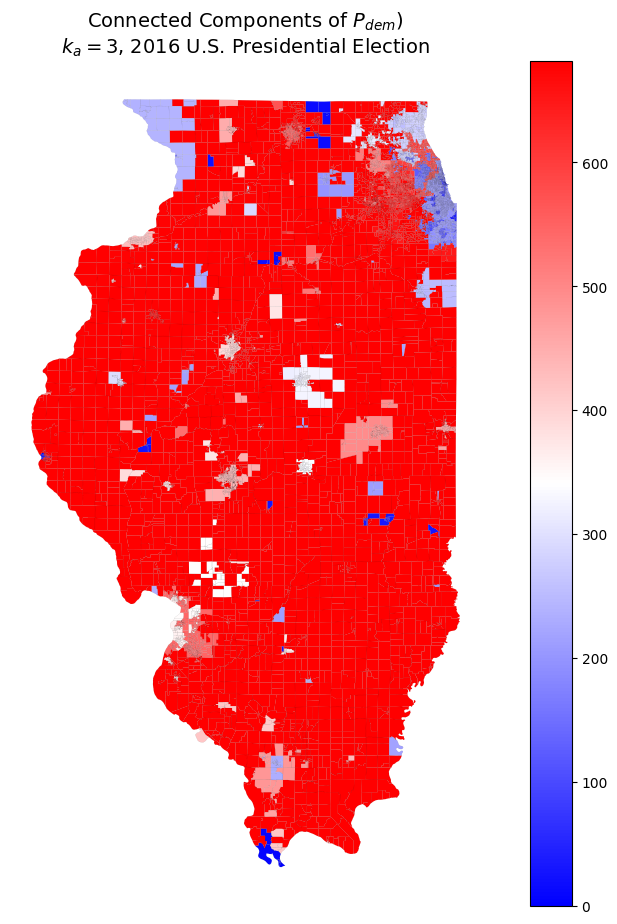

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

IL.plot(
    column="alabs",
    #categorical=True,
    cmap="bwr",
    linewidth=0.03,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title(
    "Connected Components of $P_{dem}$)\n"
    "$k_a = 3$, 2016 U.S. Presidential Election",
    fontsize=14
)


# Prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.95])
ax.set_axis_off()


In [ ]:
## Polarization Interpretation:
## S returned 0.93 and P-value of 0.001 meaning spatial polarization is significantly high.
## The statisic identifed 683 intersection components where precincts are connected based on attribute and geographic adjacency.
## The Map above shows a large republican component and less red or blue components scattered througout the state.

### Modual 2: Spatial Regimes

This section serves to form spatial regimes from the derived voteshare and Losh value of the study area. These regimes group precincts that share a similar spatial role in the polarized landscape.

Below two differnt regionalization methods are presented. Ward only merges **adjacent regions**. And SKATER builds a **minimum spanning tree (MST)** from the spatial weights graph and treats regionalization as a **graph partitioning** problem.


In [25]:
from spopt.region import WardSpatial

In [26]:
attrs = ['perdem', 'Hi']
n_clusters = 5

In [27]:
model = WardSpatial(IL, w, attrs, n_clusters=5)
model.solve()

In [28]:
IL['wardspatial5'] = model.labels_

<Axes: >

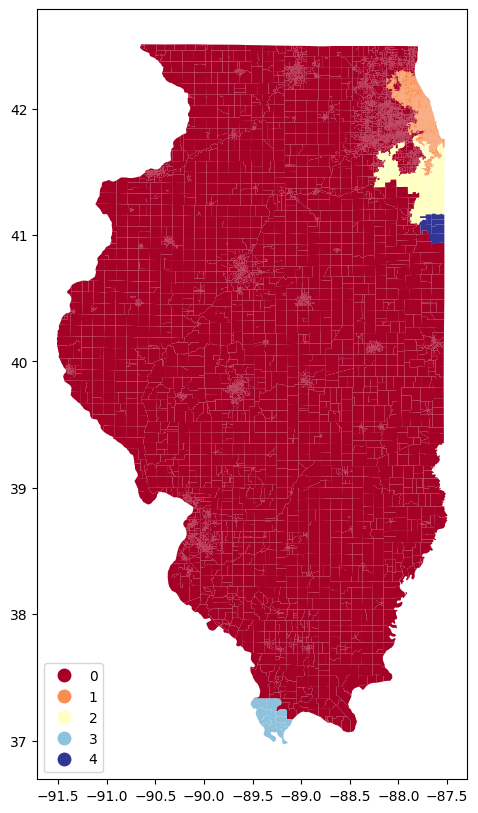

In [29]:
IL.plot(
    'wardspatial5',
    categorical=True,
    cmap="RdYlBu",
    legend=True,
    linewidth=0.05,
    figsize=(10, 10),
    legend_kwds={
        'loc': 'lower left',
        'bbox_to_anchor': (0, 0)
    }
    )

In [30]:
print(IL.groupby('wardspatial5')['perdem'].mean())

wardspatial5
0    0.446961
1    0.829762
2    0.667018
3    0.555824
4    0.473922
Name: perdem, dtype: float64


In [ ]:
## Interpreting Legend: The values above show the average vote share in each region.
## This can be used to identify partisan strongholds or conteseted zones.
## Region 1 would be considered a Democratic stronghold.

#### SKATER Regionalization

In [31]:
import spopt
from spopt.region import Skater

In [32]:
model = Skater(IL, weights, attrs, n_clusters=n_clusters)
model.solve()

/tmp/ipykernel_88814/4012979834.py:2: OptimizeWarning: By default, the graph is disconnected! Increasing `n_clusters` from 5 to 10 in order to account for islands.
  model.solve()


In [33]:
IL['skater_new_regions'] = model.labels_

<Axes: >

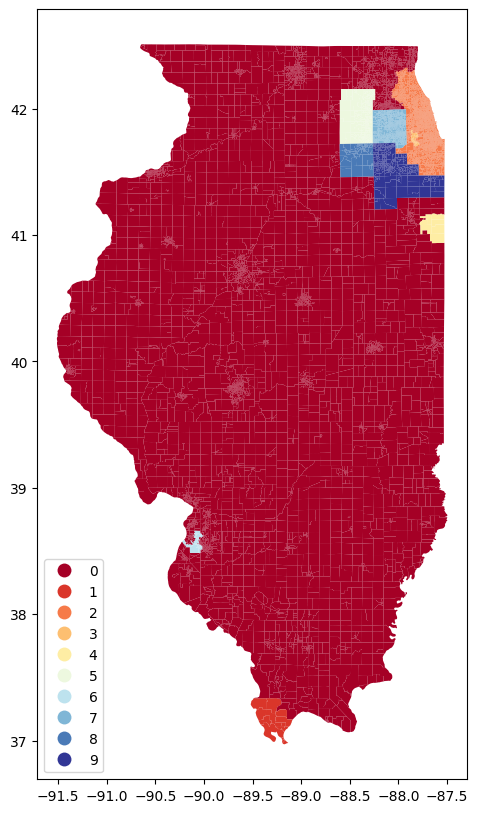

In [34]:
IL.plot(
    column='skater_new_regions',
    categorical=True,
    cmap="RdYlBu",
    legend=True,
    linewidth=0.05,
    figsize=(10, 10),
    legend_kwds={
        'loc': 'lower left',
        'bbox_to_anchor': (0, 0)
    }
    )

In [35]:
print(IL.groupby('skater_new_regions')['perdem'].mean())

skater_new_regions
0    0.402182
1    0.555824
2    0.797604
3    0.624409
4    0.473922
5    0.594084
6    0.693611
7    0.578878
8    0.490459
9    0.544237
Name: perdem, dtype: float64


### Discussion

The analysis confirms Illinois's electorate is spatially divided. The Global Moran's I (0.93) determines that the Democratic vote share across the state is non-random and highly clustered. Though by incorporating LOSH, the tension between similarity and heterogenitly is revealed.

The Local Moran clusters identify the core areas of Democratic and Republican support. The LOSH results identify the degree of variation between precincts and their neighbors. High $H_i$ values show which precincts act as political islands. For example, a Democratic precinct that is geographically isolated from other Democratic areas. In the context of spatial polarization ($S$),these islands represent the boundaries and gaps between spatial components of the electorate.

The regionalizeation modual shows the tradoff on how to define political regions. If a campaign manager were to identify regions to canvas for thier canidate, regionaliztion problem would find areas that are partisan strongholds or regions that are "contested" and could be flipped. Ward's method producded compact balanced regions that priorize geographic continuity, which tends to smooth over local variablity. In contrast, the SKATER method, prunes a miniumn spanning tree and identifies more rugged and realistic boundaries that show the sharp divides in voting behavior.

When evaluated with the intersection graph from $S$, the SKATER regions provide a higher degree of spatial partitioning. It does so by cutting edges based on the maximum dissimilarty between neighbors. Unlike Ward's, which tries to keep regions round and even, SKATER allows for irregular shapes that fallow the peaks in the data where voting results change. This suggests that the graph-based methods are more sensistve to the way groups are connected or disconnected than standard heirarchical clustering.

### Conclusion

This study confirms that voting is a spatial practice and that election results are not independently and identically distributed. By applying a spatially explicit framework to 2016 presidental election results, we can see highly clustered non random results. Integrating the methods presented above (LISA, LOSH, $S$, and Regionalization), demonsttes that the vote share is divided into specific geographic componates.

While Illinois's vote share is extremely clustered the internal structure of these clusters are complex. LOSH identifies political islands the vote share differs from its neighbors, represenitng the boundaries that define the spatial partitioning of the state. The comparision of these spatial partitions with Ward's and SKATER show that the latter method captures the rugged and realistic boundaries of these political componates.

These findings suggest that a campaign manager or political scientist can not rely on aspatial data alone. The use of the $S$ statistic alongside of thse methods provide a toolkit for measuring how the electorate is physically divided. As the boundaries between red and blue precincts harden, the ability to identify contested regions versus strongholds becomes essential for understanding the electoral landscape. While 2024 precinct results were unavailable at the time of this analysis, this workflow is fully reproducible and can be applied to any spatially referenced election data.

### Reproducibility Notes